In [1]:
!pip install -q kaggle


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle kernels pull rajmehra03/flower-recognition-cnn-keras


Source code downloaded to /content/flower-recognition-cnn-keras.ipynb


In [4]:
!kaggle datasets download -d alxmamaev/flowers-recognition


Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
 68% 152M/225M [00:00<00:00, 1.59GB/s]
100% 225M/225M [00:00<00:00, 1.01GB/s]


In [5]:
!unzip flowers-recognition.zip


Archive:  flowers-recognition.zip
  inflating: flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: flowers/daisy/10466290366_cc72e33532.jpg  
  inflating: flowers/daisy/10466558316_a7198b87e2.jpg  
  inflating: flowers/daisy/10555749515_13a12a026e.jpg  
  inflating: flowers/daisy/10555815624_dc211569b0.jpg  
  inflating: flowers/daisy/10555826524_423eb8bf71_n.jpg  
  i

In [6]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input


In [16]:
batch_size = 32
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


In [20]:
train_generator = train_datagen.flow_from_directory(
    "/content/flowers",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    "/content/flowers",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [21]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all VGG16 layers
base_model.trainable = False


In [23]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [24]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)


In [25]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [26]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3)
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 75s 647ms/step - accuracy: 0.2526 - loss: 1.9910 - val_accuracy: 0.6221 - val_loss: 1.0535 - learning_rate: 1.0000e-04
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 54s 489ms/step - accuracy: 0.4541 - loss: 1.4106 - val_accuracy: 0.7140 - val_loss: 0.8284 - learning_rate: 1.0000e-04
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 55s 507ms/step - accuracy: 0.5401 - loss: 1.1746 - val_accuracy: 0.7465 - val_loss: 0.7107 - learning_rate: 1.0000e-04
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 517ms/step - accuracy: 0.6155 - loss: 1.0274 - val_accuracy: 0.7674 - val_loss: 0.6238 - learning_rate: 1.0000e-04
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 511ms/step - accuracy: 0.6378 - loss: 0.9517 - val_accuracy: 0.7919 - val_loss: 0.5659 - learning_rate: 1.0000e-04
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 55s 505ms/step - accuracy: 0.6666 - loss: 0.8530 - val_accuracy: 0.8151 - val_loss: 0.5267 - learning_rate: 1.0000e-04
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 51

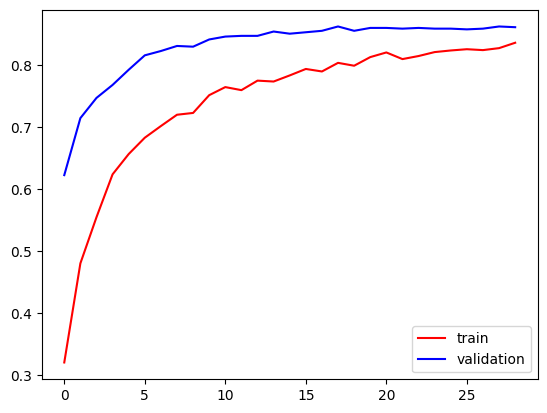

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

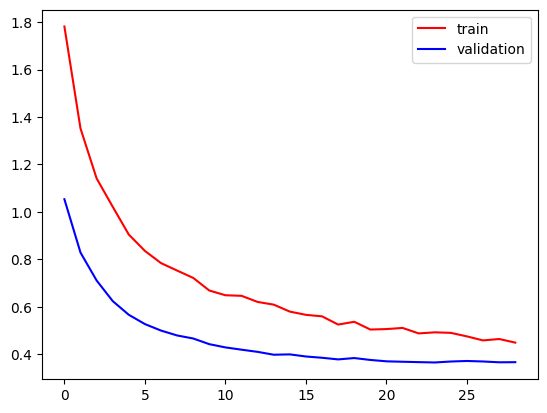

In [28]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [29]:
model.save("flowers_vgg16.keras")


In [30]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model("flowers_vgg16.keras")  # or your saved model name
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [31]:
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt

img_path = "/content/rose.jpg"  # CHANGE THIS

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)


In [33]:
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print(f"🌸 Predicted Flower: {predicted_class}")
print(f"🎯 Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 859ms/step
🌸 Predicted Flower: rose
🎯 Confidence: 50.62%


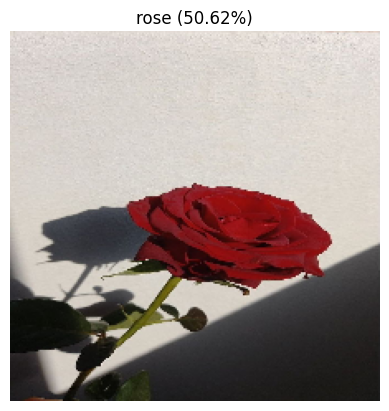

In [34]:
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()
